In [1]:
import pandas as pd
import sys
import numpy as np

In [2]:
import matplotlib.pyplot as plt

In [3]:
# make a list of file in the directory

import os

folder_of_interest_list = [
    'results_shipsnet_deterministic_00_SEU',
    'results_shipsnet_deterministic_01_SEU',
    'results_shipsnet_deterministic_02_SEU',
    'results_shipsnet_deterministic_03_SEU',
    ]

df_master = pd.read_csv(r'results_shipsnet_deterministic_00_SEU\_20250807_170542.csv')
# delete all rows leaving the columns only
# add a column called folder_name
df_master['folder_name'] = ""
df_master = df_master.drop(df_master.index)

for foil in folder_of_interest_list:

#folder_of_interest = 'results_shipsnet_01_SEU'
#folder_of_interest = 'results_GP_shipsnet_newslate_guide_SEU'

#df_master = pd.read_csv(r'results_4_variants\results_GP_shipsnet_newslate_guide_SEU\_20250718_234102.csv')
# add a column called timestamp, which is the filename without the extension
#df_master['timestamp'] = ""

    search_dir = os.path.join('',
                            foil,
    )

    for file in os.listdir(search_dir):
        if file.endswith('.csv'):
            file_path = os.path.join(search_dir, file)
            print(f"Processing file: {file_path}")
            df = pd.read_csv(file_path)
            df['folder_name'] = foil
            # remove if accuracy_after_seu is nan
            df = df[df['accuracy_after_seu'].notna()]
            print(f"Number of rows after removing NaN in 'accuracy_after_seu': {len(df)}")
            #remove duplicate rows based on the first 10 columns
            print(f"Number of rows before dropping duplicates: {len(df)}")
            df = df.drop_duplicates(subset=df.columns[:10])
            print(f"Number of rows after dropping duplicates: {len(df)}")
            # append the data to the master dataframe
            df_master = pd.concat([df_master, df], ignore_index=True)
    #

# filter accuracy_change to only non nan values
#abs_acc_change_mean = df_master[df_master['accuracy_change'].notna()]['accuracy_change'].abs().mean()
#abs_acc_change_mean\
df_master['abs_acc_diff'] = df_master['accuracy_change'].abs()
df_master['log_mean_abs_difference'] = df_master['mean_abs_difference'].apply(lambda x: np.log10(x) if x > 0 else np.nan)

Processing file: results_shipsnet_deterministic_00_SEU\_20250807_170542.csv
Number of rows after removing NaN in 'accuracy_after_seu': 48
Number of rows before dropping duplicates: 48
Number of rows after dropping duplicates: 48
Processing file: results_shipsnet_deterministic_00_SEU\_20250807_171251.csv
Number of rows after removing NaN in 'accuracy_after_seu': 48
Number of rows before dropping duplicates: 48
Number of rows after dropping duplicates: 48
Processing file: results_shipsnet_deterministic_00_SEU\_20250807_171408.csv
Number of rows after removing NaN in 'accuracy_after_seu': 48
Number of rows before dropping duplicates: 48
Number of rows after dropping duplicates: 48
Processing file: results_shipsnet_deterministic_00_SEU\_20250807_171434.csv
Number of rows after removing NaN in 'accuracy_after_seu': 48
Number of rows before dropping duplicates: 48
Number of rows after dropping duplicates: 48
Processing file: results_shipsnet_deterministic_00_SEU\_20250807_171502.csv
Number o

In [4]:
df_summary_2 = df_master.groupby(['location_layer',
                                  'location_module'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
df_summary_2

,location_layer,location_module,abs_acc_diff,softmax_difference
0,conv1,bias,0.008153,0.267989
1,conv1,weight,0.010402,0.268029
2,conv2,bias,0.003337,0.262802
3,conv2,weight,0.006908,0.264663
4,fc1,bias,0.056484,0.289209
5,fc1,weight,0.065089,0.292668


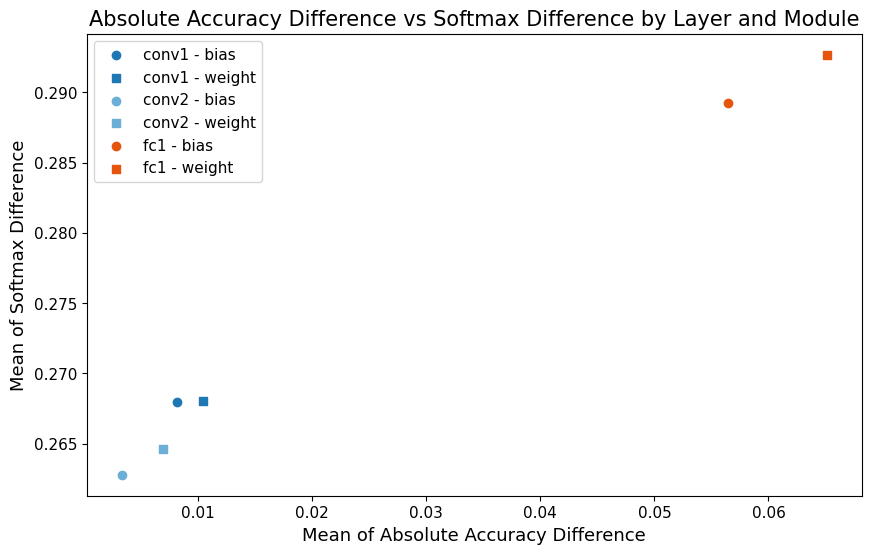

In [10]:
# make a scatter plot of abs_acc_diff vs softmax_difference
# create different shape by location_layer and location_module
plt.figure(figsize=(10, 6))
module_markers = {
    'bias': 'o',
    'weight': 's',
}
colors = {
    'conv1': '#1f77b4',
    'conv2': '#6baed6',
    'fc1':'#e6550d',
}

for layer in df_summary_2['location_layer'].unique():
    for module in df_summary_2['location_module'].unique():
        subset = df_summary_2[(df_summary_2['location_layer'] == layer) & (df_summary_2['location_module'] == module)]
        plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'], label=f'{layer} - {module}', marker=module_markers[module], color=colors[layer])
plt.xlabel('Mean of Absolute Accuracy Difference')
plt.ylabel('Mean of Softmax Difference')
plt.title('Absolute Accuracy Difference vs Softmax Difference by Layer and Module')
plt.legend()

In [6]:
df_summary_3 = df_master.groupby(['activation_fn'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
df_summary_3

,activation_fn,abs_acc_diff,softmax_difference
0,actRWG,0.013320,0.267698
1,actWG,0.030944,0.278004
2,relu,0.035840,0.287344
3,relu6,0.019212,0.269185
4,sigmoid,0.023678,0.264758
5,sin,0.024173,0.275160
6,tanh,0.028268,0.277436


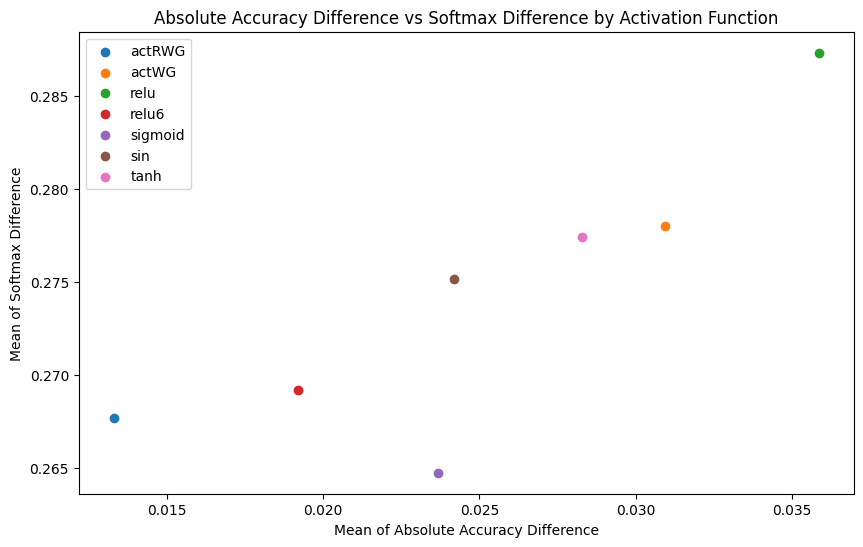

In [ ]:
# make a scatter plot of abs_acc_diff vs softmax_difference
plt.figure(figsize=(10, 6))
for activation in df_summary_3['activation_fn'].unique():
    subset = df_summary_3[df_summary_3['activation_fn'] == activation]
    plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'], label=activation)
plt.xlabel('Mean of Absolute Accuracy Difference')
plt.ylabel('Mean of Softmax Difference')
plt.title('Absolute Accuracy Difference vs Softmax Difference by Activation Function')
plt.legend()

In [8]:
df_summary = df_master.groupby(['activation_fn',
                   #'prior',
                   #'param_type',
                   'location_index',
                   'location_layer',
                   'location_module',
                   'folder_name'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
df_summary

,activation_fn,location_index,location_layer,location_module,folder_name,abs_acc_diff,softmax_difference
0,actRWG,-1,conv1,bias,results_shipsnet_deterministic_00_SEU,0.000625,0.262874
1,actRWG,-1,conv1,bias,results_shipsnet_deterministic_01_SEU,0.000937,0.264234
2,actRWG,-1,conv1,bias,results_shipsnet_deterministic_02_SEU,0.006562,0.264221
3,actRWG,-1,conv1,bias,results_shipsnet_deterministic_03_SEU,0.001562,0.258841
4,actRWG,-1,conv1,weight,results_shipsnet_deterministic_00_SEU,0.000000,0.262845
...,...,...,...,...,...,...,...
331,tanh,0,fc1,bias,results_shipsnet_deterministic_03_SEU,0.055312,0.289308
332,tanh,0,fc1,weight,results_shipsnet_deterministic_00_SEU,0.146562,0.332303
333,tanh,0,fc1,weight,results_shipsnet_deterministic_01_SEU,0.092188,0.309086
334,tanh,0,fc1,weight,results_shipsnet_deterministic_02_SEU,0.125938,0.326641


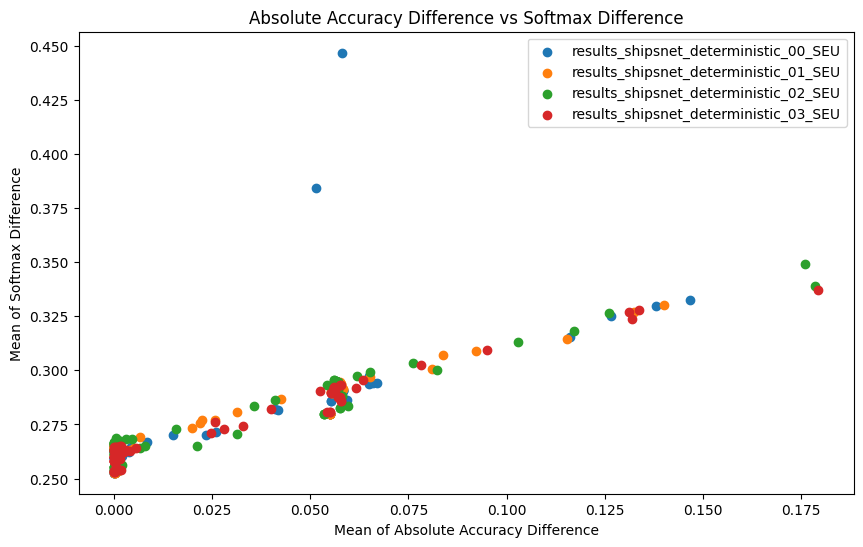

In [9]:
# make a scatter plot of abs_acc_diff vs softmax_difference
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
for folder in df_summary['folder_name'].unique():
    subset = df_summary[df_summary['folder_name'] == folder]
    plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'], label=folder)
plt.xlabel('Mean of Absolute Accuracy Difference')
plt.ylabel('Mean of Softmax Difference')
plt.title('Absolute Accuracy Difference vs Softmax Difference')
plt.legend()
plt.show()

In [10]:
df_summary_6 = df_master.groupby(['folder_name'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
df_summary_6

,folder_name,abs_acc_diff,softmax_difference
0,results_shipsnet_deterministic_00_SEU,0.025112,0.275907
1,results_shipsnet_deterministic_01_SEU,0.023571,0.273686
2,results_shipsnet_deterministic_02_SEU,0.026142,0.274426
3,results_shipsnet_deterministic_03_SEU,0.025424,0.272887


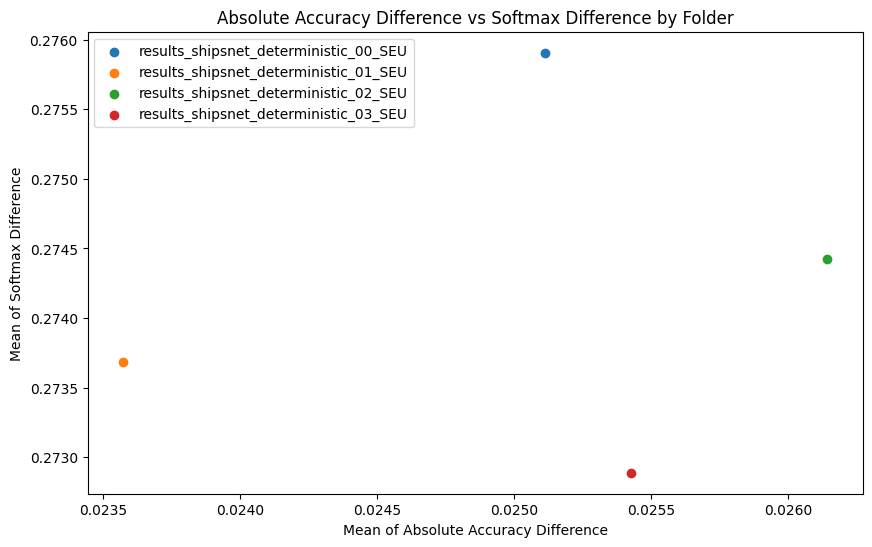

In [11]:
# make a scatter plot of abs_acc_diff vs softmax_difference from df_summary_6
plt.figure(figsize=(10, 6))
for folder in df_summary_6['folder_name'].unique():
    subset = df_summary_6[df_summary_6['folder_name'] == folder]
    plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'], label=folder)
plt.xlabel('Mean of Absolute Accuracy Difference')
plt.ylabel('Mean of Softmax Difference')
plt.title('Absolute Accuracy Difference vs Softmax Difference by Folder')
plt.legend()
plt.show()